In [6]:
import pandas as pd
import csv
import datetime
import json

def find_common_days(garmin_file, miband_file):
    # 1. Pobieranie dat z Garmina
    try:
        garmin_df = pd.read_csv(garmin_file)
        # Upewniamy się, że daty są w formacie string YYYY-MM-DD
        garmin_dates = set(garmin_df['date'].astype(str))
    except Exception as e:
        print(f"Błąd podczas czytania pliku Garmina: {e}")
        return

    # 2. Pobieranie dat z Mi Banda
    miband_dates = set()
    try:
        with open(miband_file, 'r') as f:
            reader = csv.reader(f)
            for row in reader:
                # W Twoim przykładzie 5-ta kolumna (indeks 4) to timestamp
                if len(row) >= 5:
                    try:
                        ts = int(row[4])
                        # Konwersja timestamp na datę (YYYY-MM-DD)
                        date_str = datetime.datetime.fromtimestamp(ts).strftime('%Y-%m-%d')
                        miband_dates.add(date_str)
                    except ValueError:
                        continue # Pomiń nagłówki lub błędne linie
    except Exception as e:
        print(f"Błąd podczas czytania pliku Mi Banda: {e}")
        return

    # 3. Szukanie części wspólnej (Overlap)
    common = sorted(list(garmin_dates.intersection(miband_dates)))

    # 4. Wyniki
    print("--- RAPORT SYNCHRONIZACJI ---")
    print(f"Dni w Garminie: {len(garmin_dates)}")
    print(f"Dni w Mi Bandzie: {len(miband_dates)}")
    print(f"Dni wspólne (Overlap): {len(common)}")

    if common:
        print("\nLista dni z danymi z obu urządzeń:")
        for day in common:
            print(f" - {day}")
    else:
        print("\nNie znaleziono wspólnych dni. Sprawdź, czy zakresy dat w obu plikach się pokrywają.")
        # Podpowiedź dla Ciebie
        print(f"\nPrzykładowa data Garmin: {list(garmin_dates)[0] if garmin_dates else 'Brak'}")
        print(f"Przykładowa data Mi Band: {list(miband_dates)[0] if miband_dates else 'Brak'}")

if __name__ == "__main__":
    # Podaj tutaj nazwy swoich plików
    find_common_days("../server/garmin_export.csv", "data/miband/20260318_8278074507_MiFitness_ams1_data_copy/20260318_8278074507_MiFitness_hlth_center_aggregated_fitness_data.csv")

--- RAPORT SYNCHRONIZACJI ---
Dni w Garminie: 28
Dni w Mi Bandzie: 359
Dni wspólne (Overlap): 25

Lista dni z danymi z obu urządzeń:
 - 2026-02-10
 - 2026-02-12
 - 2026-02-13
 - 2026-02-14
 - 2026-02-15
 - 2026-02-16
 - 2026-02-17
 - 2026-02-18
 - 2026-02-19
 - 2026-02-20
 - 2026-02-21
 - 2026-02-22
 - 2026-02-23
 - 2026-02-24
 - 2026-02-25
 - 2026-02-26
 - 2026-03-01
 - 2026-03-02
 - 2026-03-03
 - 2026-03-04
 - 2026-03-05
 - 2026-03-06
 - 2026-03-10
 - 2026-03-11
 - 2026-03-12


In [7]:
import pandas as pd
import csv
import datetime
import json
import os

# TWOJE ŚCIEŻKI DO PLIKÓW
GARMIN_PATH = "../server/garmin_export.csv"
MIBAND_PATH = "../data/miband/20260318_8278074507_MiFitness_ams1_data_copy/20260318_8278074507_MiFitness_hlth_center_aggregated_fitness_data.csv"
OUTPUT_FILE = "../data/garmin_test_sleep_data/comparison_final.csv"

def process_data():
    print("🚀 Rozpoczynam generowanie zestawienia porównawczego...")

    # 1. WCZYTANIE DANYCH GARMIN
    if not os.path.exists(GARMIN_PATH):
        print(f"❌ Nie znaleziono pliku Garmina pod ścieżką: {GARMIN_PATH}")
        return

    garmin_df = pd.read_csv(GARMIN_PATH)
    garmin_df['date'] = garmin_df['date'].astype(str)
    # Zmieniamy nazwy kolumn Garmina, żeby odróżnić je od Mi Banda
    garmin_df = garmin_df.rename(columns={
        'duration_min': 'garmin_total_min',
        'deep_min': 'garmin_deep_min',
        'rem_min': 'garmin_rem_min',
        'light_min': 'garmin_light_min',
        'awake_min': 'garmin_awake_min'
    })

    # 2. WCZYTANIE I PARSOWANIE DANYCH MI BAND
    if not os.path.exists(MIBAND_PATH):
        print(f"❌ Nie znaleziono pliku Mi Band pod ścieżką: {MIBAND_PATH}")
        return

    miband_records = []
    with open(MIBAND_PATH, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            # Szukamy wierszy, które mają dane o śnie (czwarta kolumna to 'sleep')
            if len(row) >= 6 and row[3] == 'sleep':
                try:
                    # Timestamp na datę
                    ts = int(row[4])
                    date_str = datetime.datetime.fromtimestamp(ts).strftime('%Y-%m-%d')

                    # Parsowanie JSON z ostatniej kolumny
                    data_json = json.loads(row[5])

                    miband_records.append({
                        "date": date_str,
                        "miband_total_min": data_json.get("total_duration", 0),
                        "miband_deep_min": data_json.get("sleep_deep_duration", 0),
                        "miband_rem_min": data_json.get("sleep_rem_duration", 0),
                        "miband_light_min": data_json.get("sleep_light_duration", 0),
                        "miband_awake_min": data_json.get("sleep_awake_duration", 0)
                    })
                except (ValueError, json.JSONDecodeError):
                    continue

    miband_df = pd.DataFrame(miband_records)

    if miband_df.empty:
        print("❌ Nie udało się wyciągnąć żadnych danych z pliku Mi Band. Sprawdź format pliku.")
        return

    # 3. ŁĄCZENIE DANYCH (INNER JOIN)
    # Zostaną tylko te daty, które są w obu plikach
    final_df = pd.merge(garmin_df, miband_df, on="date", how="inner")

    if final_df.empty:
        print("ℹ️ Brak wspólnych dni (Overlap = 0). Sprawdź czy zakresy dat się pokrywają.")
        return

    # 4. DODATKOWE OBLICZENIA (Wartość dodana do pracy licencjackiej)
    # Różnica w całkowitym czasie snu (w minutach)
    final_df['diff_total_min'] = final_df['garmin_total_min'] - final_df['miband_total_min']

    # Procentowa zgodność snu głębokiego
    # (Im bliżej 0, tym urządzenia są bardziej zgodne)
    final_df['deep_sleep_diff'] = final_df['garmin_deep_min'] - final_df['miband_deep_min']

    # 5. ZAPIS DO PLIKU
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ ZAKOŃCZONO!")
    print(f"📊 Znaleziono wspólnych dni: {len(final_df)}")
    print(f"📁 Plik wynikowy: {os.path.abspath(OUTPUT_FILE)}")
    print("\nMożesz teraz wczytać ten plik do Tableau, aby porównać urządzenia na jednym wykresie.")

if __name__ == "__main__":
    process_data()

🚀 Rozpoczynam generowanie zestawienia porównawczego...
✅ ZAKOŃCZONO!
📊 Znaleziono wspólnych dni: 42
📁 Plik wynikowy: /Users/maciejleszek/Desktop/it/bachelor/bachelor-thesis/comparison_final.csv

Możesz teraz wczytać ten plik do Tableau, aby porównać urządzenia na jednym wykresie.


✅ Wczytano dane. Usunięto 21 dni z zerowymi odczytami.
📊 Pozostało 21 dni do czystej analizy.
✅ Wykres 'sleep_comparison_clean.png' gotowy!


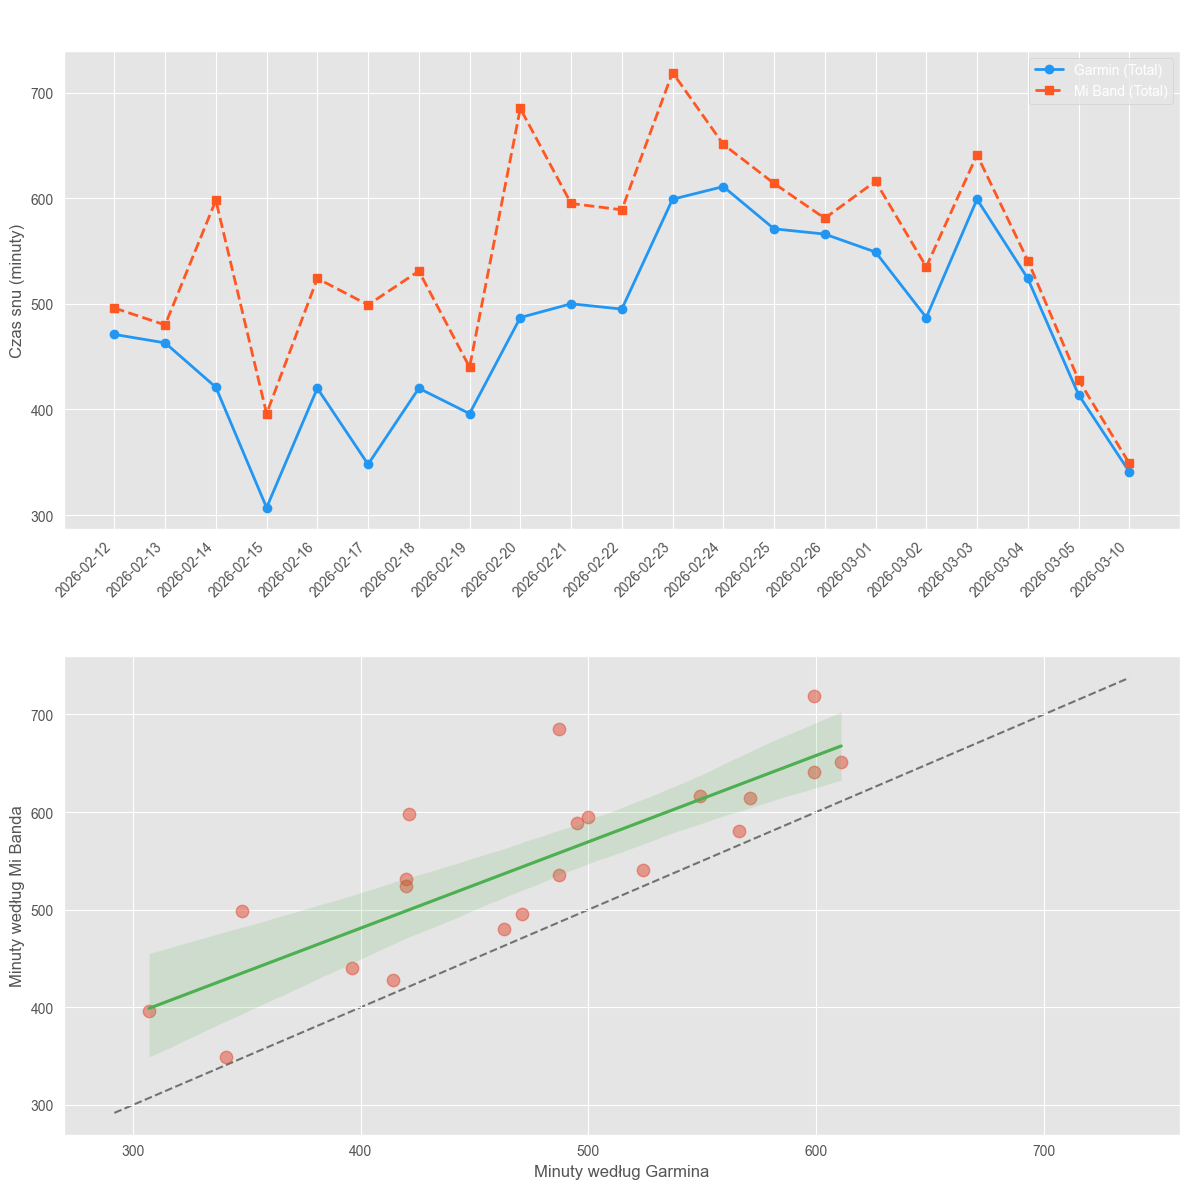

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wczytanie danych
try:
    df = pd.read_csv("../data/garmin_test_sleep_data/comparison_final.csv")
    initial_count = len(df)

    # --- FILTR: Usuwamy dni, gdzie Mi Band ma 0 w całkowitym czasie snu ---
    # Dodatkowo sprawdzamy sen głęboki, by wyeliminować niepełne pomiary
    df = df[df['miband_total_min'] > 0]
    df = df[df['miband_deep_min'] > 0]

    filtered_count = len(df)
    print(f"✅ Wczytano dane. Usunięto {initial_count - filtered_count} dni z zerowymi odczytami.")
    print(f"📊 Pozostało {filtered_count} dni do czystej analizy.")

except FileNotFoundError:
    print("❌ Nie znaleziono pliku comparison_final.csv.")
    exit()

# Ustawienie stylu
plt.style.use('ggplot') # ggplot daje bardzo "akademicki" wygląd wykresów
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- WYKRES 1: PORÓWNANIE TRENDU (LINE CHART) ---
ax1.plot(df['date'], df['garmin_total_min'], marker='o', label='Garmin (Total)', color='#2196F3', linewidth=2)
ax1.plot(df['date'], df['miband_total_min'], marker='s', label='Mi Band (Total)', color='#FF5722', linewidth=2, linestyle='--')

ax1.set_title('Porównanie czasu snu po odfiltrowaniu błędnych danych', fontsize=14, pad=20)
ax1.set_ylabel('Czas snu (minuty)')
ax1.legend()
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# --- WYKRES 2: KORELACJA (REGRESSION PLOT) ---
# Sprawdzamy jak bardzo urządzenia zgadzają się co do minut snu
sns.regplot(x='garmin_total_min', y='miband_total_min', data=df, ax=ax2,
            scatter_kws={'alpha':0.5, 's':80}, line_kws={'color':'#4CAF50'})

ax2.set_title('Korelacja: Czy urządzenia mierzą to samo?', fontsize=14, pad=20)
ax2.set_xlabel('Minuty według Garmina')
ax2.set_ylabel('Minuty według Mi Banda')

# Dodanie linii idealnej zgodności (y=x) dla porównania
lims = [
    min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
    max(ax2.get_xlim()[1], ax2.get_ylim()[1])
]
ax2.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label='Idealna zgodność')

plt.tight_layout()
plt.savefig('sleep_comparison_clean.png')
print("✅ Wykres 'sleep_comparison_clean.png' gotowy!")
plt.show()

✅ Oczyszczono dane. Analizuję 21 pełnych nocy.
✅ Wygenerowano zaawansowane wykresy: advanced_sleep_analysis.png


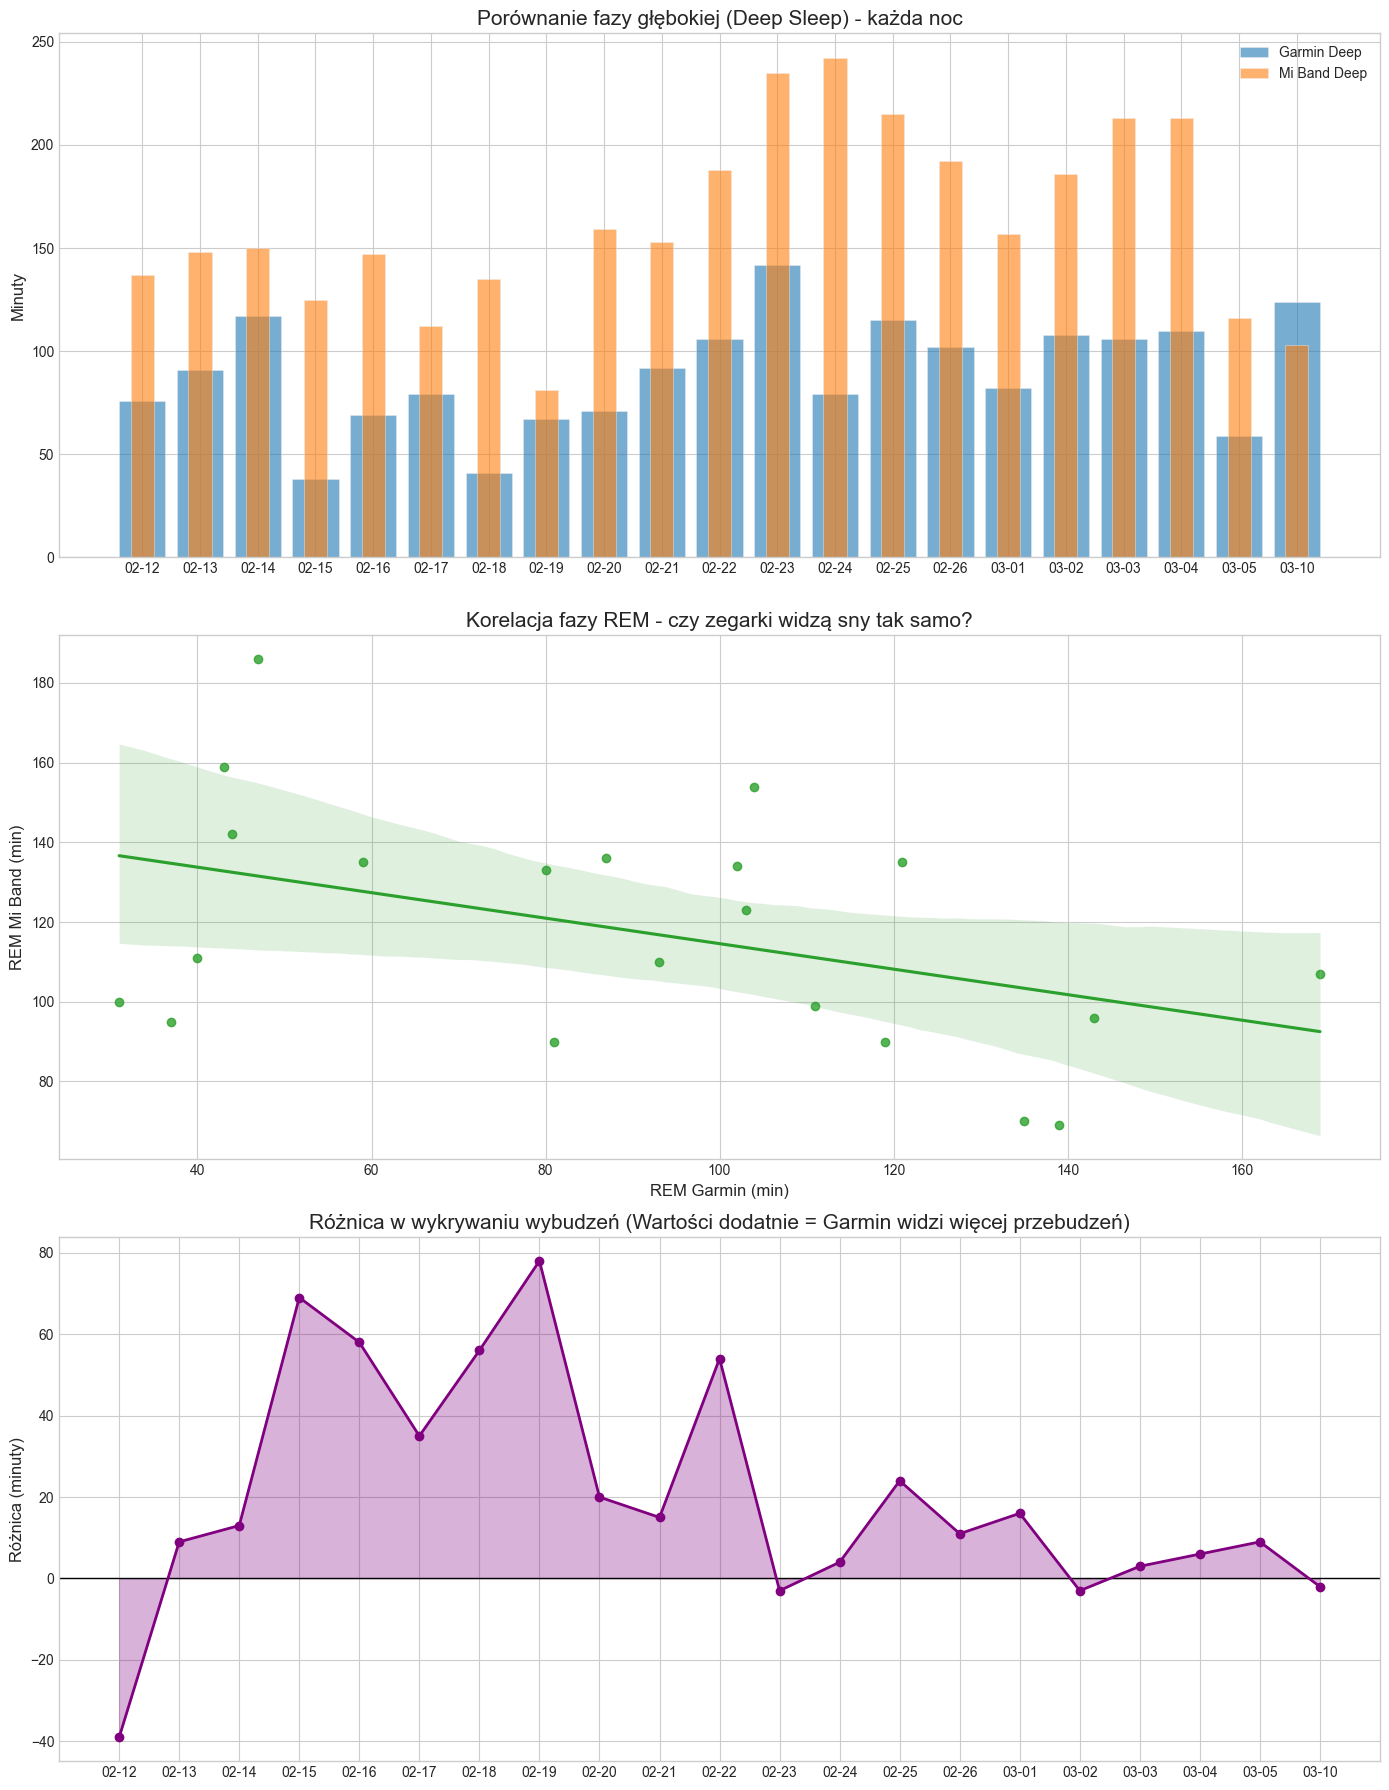

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wczytanie i czyszczenie danych
df = pd.read_csv("../data/garmin_test_sleep_data/comparison_final.csv")

# Usuwamy wiersze, gdzie miband_total_min jest zerem (błędne rekordy)
df_clean = df[df['miband_total_min'] > 0].copy()

# Konwersja daty na ładniejszy format do wykresu
df_clean['date'] = pd.to_datetime(df_clean['date']).dt.strftime('%m-%d')

print(f"✅ Oczyszczono dane. Analizuję {len(df_clean)} pełnych nocy.")

# 2. Ustawienie stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# --- WYKRES 1: DEEP SLEEP COMPARISON (Błąd pomiaru) ---
axes[0].bar(df_clean['date'], df_clean['garmin_deep_min'], alpha=0.6, label='Garmin Deep', color='#1f77b4')
axes[0].bar(df_clean['date'], df_clean['miband_deep_min'], alpha=0.6, label='Mi Band Deep', color='#ff7f0e', width=0.4)
axes[0].set_title('Porównanie fazy głębokiej (Deep Sleep) - każda noc', fontsize=15)
axes[0].set_ylabel('Minuty')
axes[0].legend()

# --- WYKRES 2: REM SLEEP COMPARISON (Korelacja) ---
sns.regplot(x='garmin_rem_min', y='miband_rem_min', data=df_clean, ax=axes[1], color='#2ca02c')
axes[1].set_title('Korelacja fazy REM - czy zegarki widzą sny tak samo?', fontsize=15)
axes[1].set_xlabel('REM Garmin (min)')
axes[1].set_ylabel('REM Mi Band (min)')

# --- WYKRES 3: AWAKE TIME (Analiza różnic) ---
# Obliczamy różnicę w wykrywaniu przebudzeń
df_clean['awake_diff'] = df_clean['garmin_awake_min'] - df_clean['miband_awake_min']
axes[2].axhline(0, color='black', linewidth=1)
axes[2].fill_between(df_clean['date'], df_clean['awake_diff'], color='purple', alpha=0.3)
axes[2].plot(df_clean['date'], df_clean['awake_diff'], color='purple', marker='o', linewidth=2)
axes[2].set_title('Różnica w wykrywaniu wybudzeń (Wartości dodatnie = Garmin widzi więcej przebudzeń)', fontsize=15)
axes[2].set_ylabel('Różnica (minuty)')

# Finalne szlify
plt.tight_layout()
plt.savefig('advanced_sleep_analysis.png')
print("✅ Wygenerowano zaawansowane wykresy: advanced_sleep_analysis.png")
plt.show()

✅ Dane oczyszczone. Liczba nocy do analizy: 21

📊 STATYSTYKI ZBIORCZE:
   Parametr  Korelacja  MAE (min)
Total Sleep       0.82      72.33
 Deep Sleep       0.53      75.00
  REM Sleep      -0.43      55.05
Light Sleep       0.60      67.29
 Awake Time       0.39      25.10


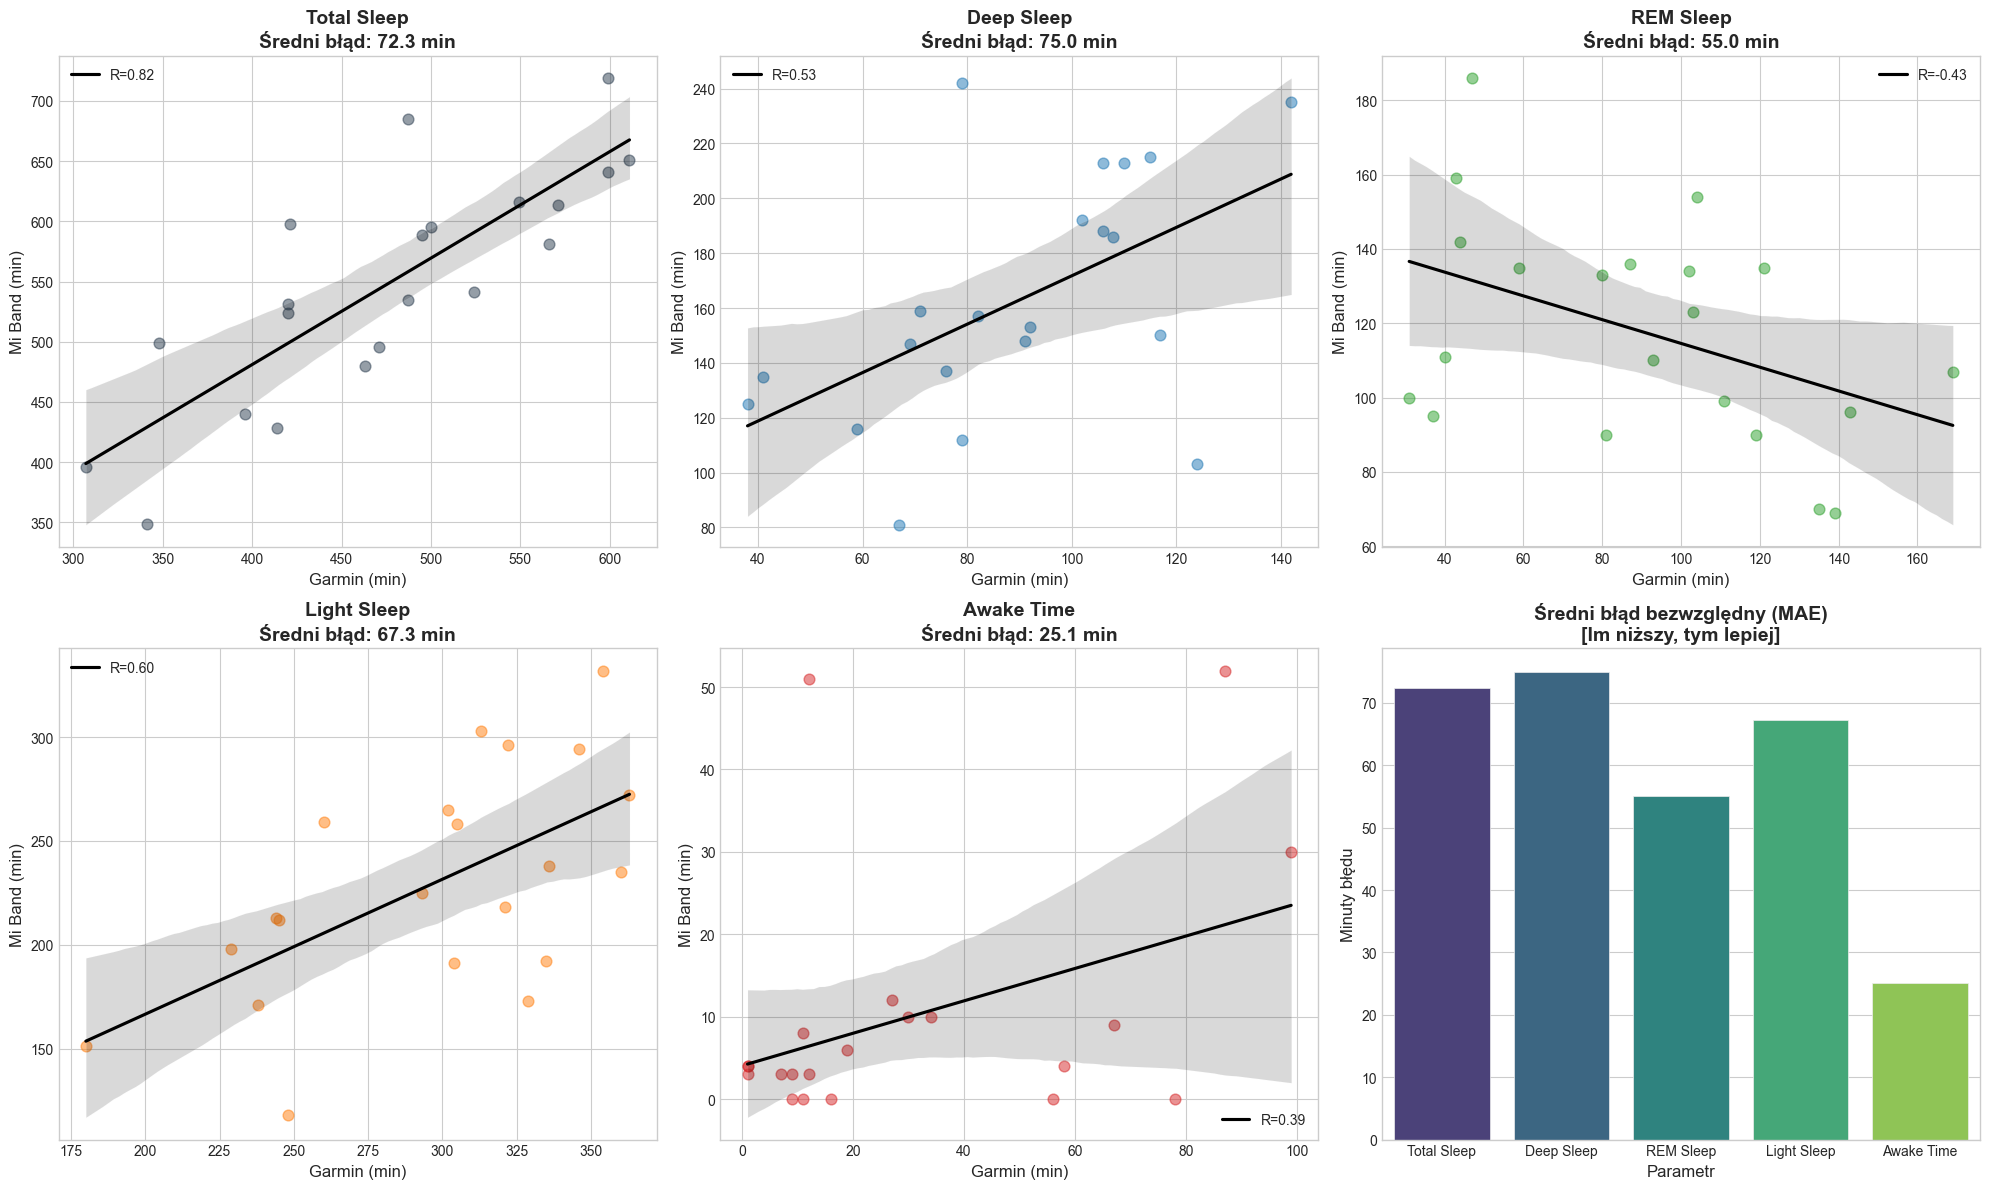

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Wczytanie danych
try:
    df = pd.read_csv("../data/garmin_test_sleep_data/comparison_final.csv")

    # --- CZYSZCZENIE DANYCH ---
    # 1. Usuwamy wiersze, gdzie Mi Band ma 0 (błędy)
    df = df[df['miband_total_min'] > 0]

    # 2. Usuwamy duplikaty dat, zostawiając tylko te z największą ilością snu
    # (to eliminuje puste wiersze, jeśli zostały w pliku)
    df = df.sort_values('miband_total_min', ascending=False).drop_duplicates('date').sort_values('date')

    print(f"✅ Dane oczyszczone. Liczba nocy do analizy: {len(df)}")
except FileNotFoundError:
    print("❌ Nie znaleziono pliku. Upewnij się, że 'comparison_final.csv' jest w folderze.")
    exit()

# 2. Definicja parametrów do porównania
params = [
    ('Total Sleep', 'garmin_total_min', 'miband_total_min', '#2c3e50'),
    ('Deep Sleep', 'garmin_deep_min', 'miband_deep_min', '#1f77b4'),
    ('REM Sleep', 'garmin_rem_min', 'miband_rem_min', '#2ca02c'),
    ('Light Sleep', 'garmin_light_min', 'miband_light_min', '#ff7f0e'),
    ('Awake Time', 'garmin_awake_min', 'miband_awake_min', '#d62728')
]

# Przygotowanie statystyk
stats_list = []

# 3. Tworzenie wykresów (2 wiersze, 3 kolumny)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (title, g_col, m_col, color) in enumerate(params):
    # Obliczenia
    corr = df[g_col].corr(df[m_col])
    mae = np.abs(df[g_col] - df[m_col]).mean()
    stats_list.append({'Parametr': title, 'Korelacja': corr, 'MAE (min)': mae})

    # Wykres rozrzutu z regresją
    sns.regplot(x=g_col, y=m_col, data=df, ax=axes[i],
                scatter_kws={'alpha':0.5, 's':60, 'color': color},
                line_kws={'color': 'black', 'label': f'R={corr:.2f}'})

    axes[i].set_title(f'{title}\nŚredni błąd: {mae:.1f} min', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(f'Garmin (min)')
    axes[i].set_ylabel(f'Mi Band (min)')
    axes[i].legend()

# 4. Wykres podsumowujący błędy (Tu poprawka dla Seaborn v0.14)
stats_df = pd.DataFrame(stats_list)
sns.barplot(
    x='Parametr',
    y='MAE (min)',
    data=stats_df,
    ax=axes[5],
    hue='Parametr',  # Przypisanie x do hue naprawia ostrzeżenie
    palette='viridis',
    legend=False     # Ukrywamy legendę, bo x już opisuje słupki
)
axes[5].set_title('Średni błąd bezwzględny (MAE)\n[Im niższy, tym lepiej]', fontsize=14, fontweight='bold')
axes[5].set_ylabel('Minuty błędu')

plt.tight_layout()
plt.savefig('comparative_analysis_fixed.png', dpi=300)
print("\n📊 STATYSTYKI ZBIORCZE:")
print(stats_df.round(2).to_string(index=False))
plt.show()